Spam Email Classifier

Problem Statement
The objective of this project is to classify emails as spam or non-spam using machine learning models.

The project includes:

Text preprocessing
Exploratory Data Analysis (EDA)
TF-IDF Vectorization
Model comparison
Performance evaluation

In [99]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import nltk
import string
import pickle

from collections import Counter

from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.model_selection import train_test_split

from sklearn.naive_bayes import (
    MultinomialNB,
    GaussianNB,
    BernoulliNB
)

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier,
    BaggingClassifier,
    ExtraTreesClassifier
)

from sklearn.neighbors import KNeighborsClassifier

from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    confusion_matrix,
    classification_report
)

In [10]:
!pip install jedi

In [101]:
df = pd.read_csv('spam_email_dataset.csv', encoding='latin1')

In [102]:
df.sample(5)

,email_id,subject,email_text,num_words,num_characters,num_exclamation_marks,num_links,has_suspicious_link,num_attachments,has_attachment,sender_email,sender_domain,sender_reputation_score,email_hour,email_day_of_week,is_weekend,num_recipients,contains_money_terms,contains_urgency_terms,label
8,8,Meeting Reminder,team sync - Organization easy course goal. Rec...,14,95,0,8,1,2,1,iksrgyl@company.com,company.com,0.87,19,1,0,21,0,0,0
376,376,Project Update,meeting - Listen require law eat apply sort. P...,12,75,0,1,0,2,1,tsgqrve@yahoo.com,yahoo.com,0.66,10,5,1,19,0,1,0
3485,3485,Meeting Reminder,report - Anyone central what strong.,6,36,0,4,0,0,0,vmxlmmt@yahoo.com,yahoo.com,0.93,0,5,1,4,0,1,0
2529,2529,Meeting Reminder,team sync - Take teach despite. Feel subject p...,11,63,0,6,0,1,1,ubwdljp@gmail.com,gmail.com,0.61,3,0,0,2,0,0,0
9082,9082,Schedule Confirmation,schedule - Deal plan draw opportunity artist. ...,14,88,0,3,1,0,0,mqmqbfj@company.com,company.com,0.66,6,5,1,24,0,0,0


In [9]:
df['email_text']

0       budget review - Statement our I claim world st...
1       team sync - President series today already. In...
2       win free urgent offer limited limited urgent u...
3       guarantee click now cash offer click now guara...
4       team sync - Significant property hotel not add...
                              ...                        
9995    free win cash win guarantee urgent free win li...
9996    click now free guarantee free win click now wi...
9997    offer cash win limited click now cash limited ...
9998             budget review - Many result affect idea.
9999    budget review - Day measure few alone decade a...
Name: email_text, Length: 10000, dtype: object

In [119]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   email_id                 10000 non-null  int64  
 1   subject                  10000 non-null  object 
 2   email_text               10000 non-null  object 
 3   num_words                10000 non-null  int64  
 4   num_characters           10000 non-null  int64  
 5   num_exclamation_marks    10000 non-null  int64  
 6   num_links                10000 non-null  int64  
 7   has_suspicious_link      10000 non-null  int64  
 8   num_attachments          10000 non-null  int64  
 9   has_attachment           10000 non-null  int64  
 10  sender_email             10000 non-null  object 
 11  sender_domain            10000 non-null  object 
 12  sender_reputation_score  10000 non-null  float64
 13  email_hour               10000 non-null  int64  
 14  email_day_of_week      

In [29]:

!pip install nltk

In [32]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.


True

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [40]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


True

In [ ]:
DATA CLEANING
Performed:

Removed unnecessary columns
Combined subject and email text
Checked missing values
Prepared dataset for NLP preprocessing

In [103]:
df.isnull().sum()

email_id                   0
subject                    0
email_text                 0
num_words                  0
num_characters             0
num_exclamation_marks      0
num_links                  0
has_suspicious_link        0
num_attachments            0
has_attachment             0
sender_email               0
sender_domain              0
sender_reputation_score    0
email_hour                 0
email_day_of_week          0
is_weekend                 0
num_recipients             0
contains_money_terms       0
contains_urgency_terms     0
label                      0
dtype: int64

In [104]:
df['num_sentences'] = df['email_text'].apply(
    lambda x: len(nltk.sent_tokenize(str(x)))
)

In [106]:
df.sample()

,email_id,subject,email_text,num_words,num_characters,num_exclamation_marks,num_links,has_suspicious_link,num_attachments,has_attachment,...,sender_domain,sender_reputation_score,email_hour,email_day_of_week,is_weekend,num_recipients,contains_money_terms,contains_urgency_terms,label,num_sentences
6779,6779,Project Update,team sync - Draw chair try especially. Would w...,15,96,0,1,0,2,1,...,gmail.com,0.64,9,0,0,6,0,0,0,2


In [107]:
corr = df.corr(numeric_only=True)

corr['label'].sort_values(ascending=False)

label                      1.000000
contains_money_terms       0.494995
contains_urgency_terms     0.483589
num_words                  0.427806
num_characters             0.391777
num_links                 -0.000927
email_hour                -0.002530
email_id                  -0.007863
has_suspicious_link       -0.010013
num_recipients            -0.013050
is_weekend                -0.013974
email_day_of_week         -0.022952
has_attachment            -0.171841
num_attachments           -0.333137
sender_reputation_score   -0.496663
num_sentences             -0.776616
num_exclamation_marks           NaN
Name: label, dtype: float64

In [ ]:
wordcloud
correlation heatmap

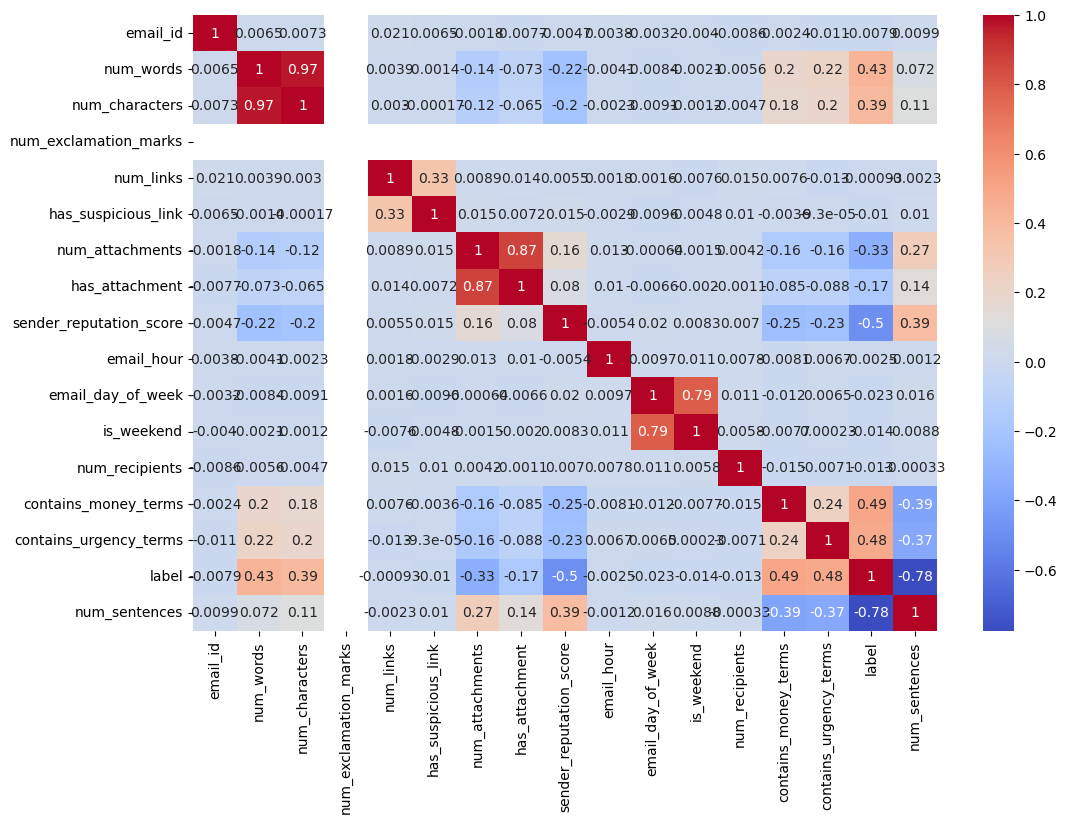

In [108]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

In [109]:
df=df[['subject','email_text','num_words','num_characters','contains_money_terms','contains_urgency_terms','num_sentences','label']]

In [110]:
df.shape


(10000, 8)

In [111]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   subject                 10000 non-null  object
 1   email_text              10000 non-null  object
 2   num_words               10000 non-null  int64 
 3   num_characters          10000 non-null  int64 
 4   contains_money_terms    10000 non-null  int64 
 5   contains_urgency_terms  10000 non-null  int64 
 6   num_sentences           10000 non-null  int64 
 7   label                   10000 non-null  int64 
dtypes: int64(6), object(2)
memory usage: 625.1+ KB


In [112]:
df.duplicated().sum()

np.int64(0)

In [126]:
# Fixed the mismatched quotes - now using consistent single quotes
df[df['label'] == 0].describe()

,email_id,num_words,num_characters,num_exclamation_marks,num_links,has_suspicious_link,num_attachments,has_attachment,sender_reputation_score,email_hour,email_day_of_week,is_weekend,num_recipients,contains_money_terms,contains_urgency_terms,label,num_sentences
count,6005.000000,6005.000000,6005.000000,6005.0,6005.000000,6005.000000,6005.000000,6005.000000,6005.000000,6005.000000,6005.000000,6005.000000,6005.000000,6005.000000,6005.000000,6005.0,6005.000000
mean,5018.013322,16.295254,104.278102,0.0,3.978351,0.470774,1.007993,0.668276,0.751980,11.603830,3.043297,0.292256,15.593172,0.200833,0.302082,0.0,2.502415
std,2884.605102,4.896863,33.272284,0.0,2.574124,0.499187,0.819444,0.470871,0.143797,6.926695,2.004107,0.454837,8.726974,0.400656,0.459199,0.0,0.770372
min,0.000000,5.000000,25.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.500000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.0,1.000000
25%,2515.000000,13.000000,81.000000,0.0,2.000000,0.000000,0.000000,0.000000,0.630000,6.000000,1.000000,0.000000,8.000000,0.000000,0.000000,0.0,2.000000
50%,5066.000000,16.000000,103.000000,0.0,4.000000,0.000000,1.000000,1.000000,0.750000,12.000000,3.000000,0.000000,16.000000,0.000000,0.000000,0.0,3.000000
75%,7509.000000,20.000000,127.000000,0.0,6.000000,1.000000,2.000000,1.000000,0.870000,18.000000,5.000000,1.000000,23.000000,0.000000,1.000000,0.0,3.000000
max,9999.000000,33.000000,214.000000,0.0,8.000000,1.000000,2.000000,1.000000,1.000000,23.000000,6.000000,1.000000,30.000000,1.000000,1.000000,0.0,4.000000


In [52]:
# Fixed the mismatched quotes - now using consistent single quotes
df[df['label'] == 1].describe()

,num_words,num_characters,contains_money_terms,contains_urgency_terms,num_sentences,label
count,3995.000000,3995.000000,3995.000000,3995.000000,3995.0,3995.0
mean,20.805257,131.297622,0.695620,0.795745,1.0,1.0
std,4.300042,27.463679,0.460202,0.403207,0.0,0.0
min,11.000000,57.000000,0.000000,0.000000,1.0,1.0
25%,18.000000,112.000000,0.000000,1.000000,1.0,1.0
50%,21.000000,131.000000,1.000000,1.000000,1.0,1.0
75%,24.000000,151.000000,1.000000,1.000000,1.0,1.0
max,33.000000,221.000000,1.000000,1.000000,1.0,1.0


In [ ]:
#Spam emails are:

longer in text size
but written in fewer sentences
More sentences.
More natural structure.
More conversational formatting.

strong indicator
money term
urgency term
Spam sentence count has:

mean = 1
std = 0
Almost every spam email has exactly 1 sentence.

In [20]:

df['label'].value_counts()

label
0    6005
1    3995
Name: count, dtype: int64

In [ ]:
EDA
pam vs ham countplot
word count comparison


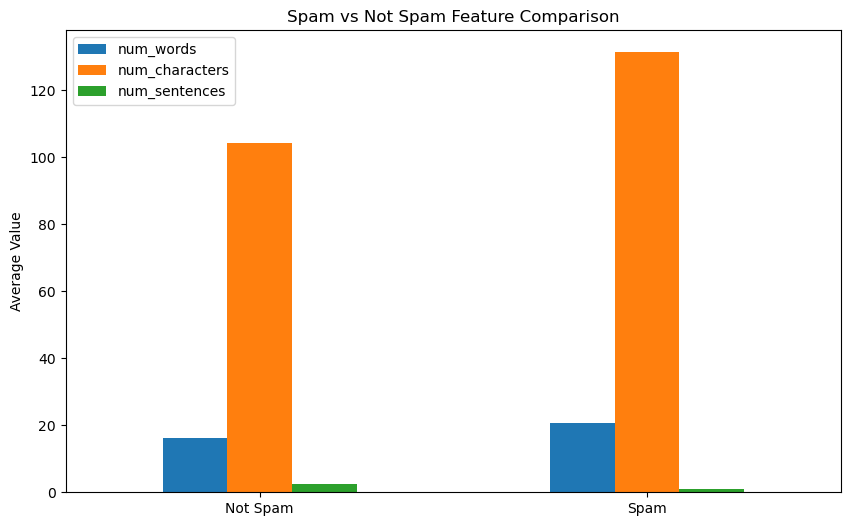

In [206]:
import matplotlib.pyplot as plt
import seaborn as sns

grouped = df.groupby('label')[
    ['num_words', 'num_characters', 'num_sentences']
].mean()

grouped.index = ['Not Spam', 'Spam']

grouped.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title('Spam vs Not Spam Feature Comparison')

plt.ylabel('Average Value')

plt.xticks(rotation=0)

plt.show()

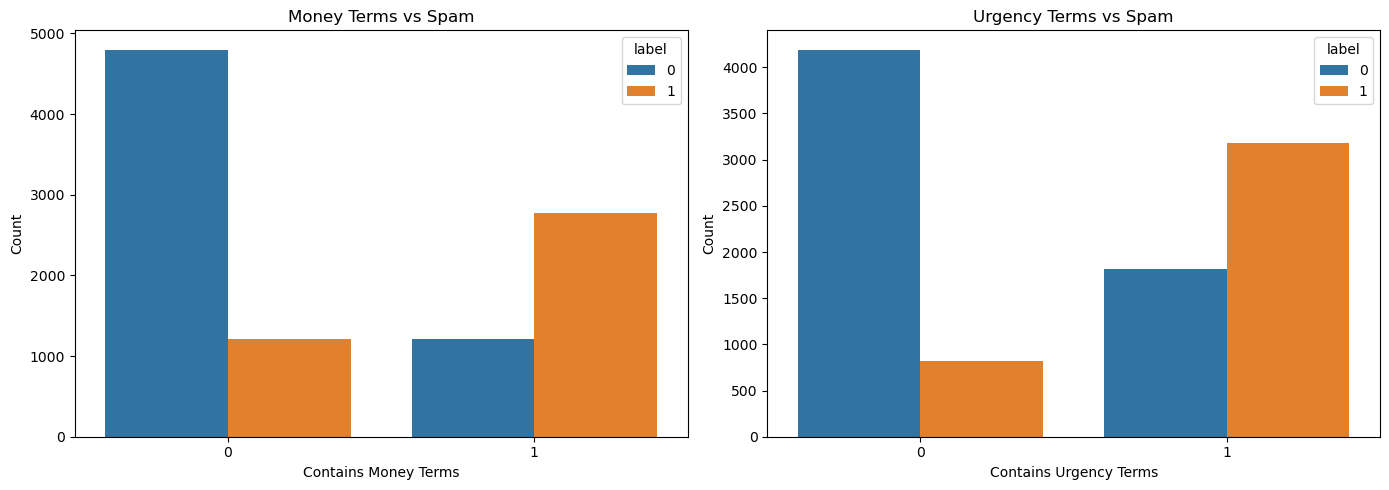

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Money terms graph
sns.countplot(
    x='contains_money_terms',
    hue='label',
    data=df,
    ax=axes[0]
)

axes[0].set_title('Money Terms vs Spam')
axes[0].set_xlabel('Contains Money Terms')
axes[0].set_ylabel('Count')

# Urgency terms graph
sns.countplot(
    x='contains_urgency_terms',
    hue='label',
    data=df,
    ax=axes[1]
)

axes[1].set_title('Urgency Terms vs Spam')
axes[1].set_xlabel('Contains Urgency Terms')
axes[1].set_ylabel('Count')

plt.tight_layout()

plt.show()

In [ ]:
At contains_money_terms = 0

Not spam emails are VERY high
Spam emails are low

Meaning:

If money-related words are absent, email is usually not spam.

In [58]:
import nltk

nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [113]:
ps = PorterStemmer()

In [117]:
df.head()

,subject,email_text,num_words,num_characters,contains_money_terms,contains_urgency_terms,num_sentences,label
0,Weekly Report,budget review - Statement our I claim world st...,19,114,0,0,3,0
1,Project Update,team sync - President series today already. In...,18,114,1,0,3,0
2,ð¥WIN BIG NOW!!,win free urgent offer limited limited urgent u...,19,126,1,1,1,1
3,ð¥WIN BIG NOW!!,guarantee click now cash offer click now guara...,16,101,1,1,1,1
4,Meeting Reminder,team sync - Significant property hotel not add...,18,111,0,0,3,0


In [116]:
def transform_text(text):

    text=text.lower()

    text=nltk.word_tokenize(text)

    y=[]

    for i in text:
        if  i.isalnum():
            y.append(i)

    
    text = y[:]
    y.clear()

    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)

    text = y[:]
    y.clear()

    for i in text:
        y.append(ps.stem(i))

    return " ".join(y)


    


In [68]:
df['email_text'][12]

'guarantee click now free urgent limited guarantee cash limited Sister fill after teacher them quality.'

In [70]:
transform_text('limited win cash limited click now Up understand off rise free large thing tough meeting.')

'limit win cash limit click understand rise free larg thing tough meet'

In [118]:
df['transformed_text'] = df['email_text'].apply(transform_text)

In [119]:
df[['email_text', 'transformed_text']].head()

,email_text,transformed_text
0,budget review - Statement our I claim world st...,budget review statement claim world star entir...
1,team sync - President series today already. In...,team sync presid seri today alreadi involv los...
2,win free urgent offer limited limited urgent u...,win free urgent offer limit limit urgent urgen...
3,guarantee click now cash offer click now guara...,guarante click cash offer click guarante prope...
4,team sync - Significant property hotel not add...,team sync signific properti hotel address mone...


In [140]:
df[df['label'] == 1]['subject'].head(20)

2            ð¥WIN BIG NOW!!
3            ð¥WIN BIG NOW!!
7          You are selected!!!
10           ð¥WIN BIG NOW!!
11           ð¥WIN BIG NOW!!
12         You are selected!!!
21    URGENT: Cliam your prize
22         You are selected!!!
23         You are selected!!!
26         You are selected!!!
27            Limited Offer!!!
28            Limited Offer!!!
29    URGENT: Cliam your prize
34            Limited Offer!!!
36            Limited Offer!!!
45            Limited Offer!!!
48            Limited Offer!!!
49            Limited Offer!!!
51           ð¥WIN BIG NOW!!
52         You are selected!!!
Name: subject, dtype: object

In [79]:
df[df['label'] == 0]['subject'].head(20)

0             Weekly Report
1            Project Update
4          Meeting Reminder
5     Schedule Confirmation
6             Weekly Report
8          Meeting Reminder
9            Project Update
13         Meeting Reminder
14            Weekly Report
15    Schedule Confirmation
16            Weekly Report
17         Meeting Reminder
18            Weekly Report
19            Weekly Report
20         Meeting Reminder
24            Weekly Report
25    Schedule Confirmation
30    Schedule Confirmation
31    Schedule Confirmation
32           Project Update
Name: subject, dtype: object

In [24]:
df['subject_length'] = df['subject'].apply(len)

In [25]:
df.groupby('label')['subject_length'].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,6005.0,16.064280,3.105871,13.0,14.0,16.0,21.0,21.0
1,3995.0,19.041051,3.098179,16.0,17.0,19.0,24.0,24.0


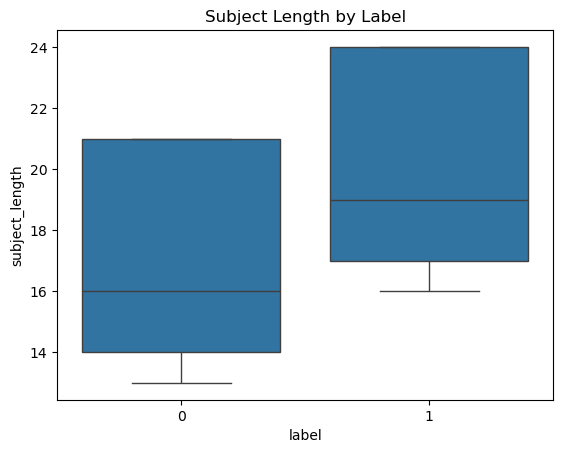

In [212]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(
    x='label',
    y='subject_length',
    data=df
)

plt.title('Subject Length by Label')

plt.show()

In [26]:
df['subject_word_count'] = df['subject'].apply(
    lambda x: len(str(x).split())
)

In [27]:
df.groupby('label')['subject_word_count'].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,6005.0,2.000000,0.00000,2.0,2.0,2.0,2.0,2.0
1,3995.0,3.010513,0.70756,2.0,3.0,3.0,4.0,4.0


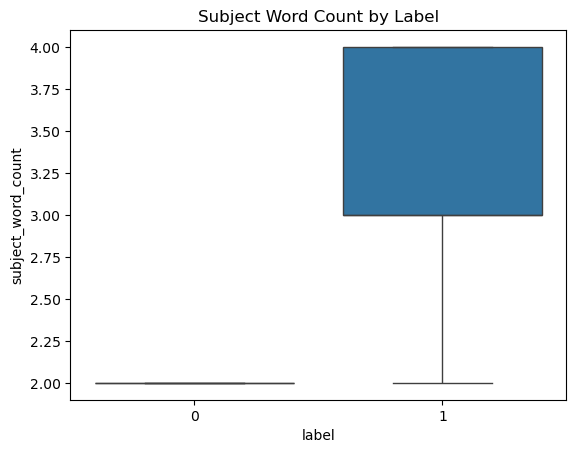

In [215]:
sns.boxplot(
    x='label',
    y='subject_word_count',
    data=df
)

plt.title('Subject Word Count by Label')

plt.show()

In [28]:
def uppercase_ratio(text):

    total_chars = len(text)

    if total_chars == 0:
        return 0

    upper_chars = sum(1 for c in text if c.isupper())

    return upper_chars / total_chars

In [29]:
df['subject_uppercase_ratio'] = df['subject'].apply(uppercase_ratio)

In [30]:
df.groupby('label')['subject_uppercase_ratio'].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,6005.0,0.128773,0.022281,0.095238,0.095238,0.125000,0.142857,0.153846
1,3995.0,0.251039,0.183150,0.052632,0.125000,0.291667,0.529412,0.529412


In [31]:
df['subject_exclamation_count'] = df['subject'].apply(
    lambda x: str(x).count('!')
)

In [32]:
df.groupby('label')['subject_exclamation_count'].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,6005.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
1,3995.0,1.982478,1.231246,0.0,0.0,2.0,3.0,3.0


In [33]:
spam_subjects = " ".join(
    df[df['label']==1]['subject'].astype(str)
)

In [34]:
from collections import Counter

spam_words = Counter(
    spam_subjects.lower().split()
).most_common(20)

print(spam_words)

[('urgent:', 1021), ('cliam', 1021), ('your', 1021), ('prize', 1021), ('ð\x9f\x94¥win', 1002), ('big', 1002), ('now!!', 1002), ('you', 993), ('are', 993), ('selected!!!', 993), ('limited', 979), ('offer!!!', 979)]


In [35]:
ham_subjects = " ".join(
    df[df['label']==0]['subject'].astype(str)
)

ham_words = Counter(
    ham_subjects.lower().split()
).most_common(20)

print(ham_words)

[('schedule', 1553), ('confirmation', 1553), ('project', 1510), ('update', 1510), ('meeting', 1489), ('reminder', 1489), ('weekly', 1453), ('report', 1453)]


In [36]:
corr = df[
    [
        'subject_length',
        'subject_word_count',
        'subject_uppercase_ratio',
        'subject_exclamation_count',
        'label'
    ]
].corr()

print(corr['label'])

subject_length               0.425323
subject_word_count           0.742015
subject_uppercase_ratio      0.455540
subject_exclamation_count    0.780352
label                        1.000000
Name: label, dtype: float64


In [37]:
df['text']=df['subject']+df['email_text']

In [229]:
df.head()

,subject,email_text,num_words,num_characters,contains_money_terms,contains_urgency_terms,num_sentences,label,subject_length,subject_word_count,subject_uppercase_ratio,subject_exclamation_count,text
0,Weekly Report,budget review - Statement our I claim world st...,19,114,0,0,3,0,13,2,0.153846,0,Weekly Reportbudget review - Statement our I c...
1,Project Update,team sync - President series today already. In...,18,114,1,0,3,0,14,2,0.142857,0,Project Updateteam sync - President series tod...
2,ð¥WIN BIG NOW!!,win free urgent offer limited limited urgent u...,19,126,1,1,1,1,17,3,0.529412,2,ð¥WIN BIG NOW!!win free urgent offer limited...
3,ð¥WIN BIG NOW!!,guarantee click now cash offer click now guara...,16,101,1,1,1,1,17,3,0.529412,2,ð¥WIN BIG NOW!!guarantee click now cash offe...
4,Meeting Reminder,team sync - Significant property hotel not add...,18,111,0,0,3,0,16,2,0.125000,0,Meeting Reminderteam sync - Significant proper...


In [38]:
df = df.drop(
    columns=[
        'subject',
        'email_text',
        'subject_length',
        'subject_word_count',
        'subject_uppercase_ratio',
        'subject_exclamation_count'
    ]
)

In [39]:
df['transformed_text'] = df['text'].apply(transform_text)

In [41]:
df[['text', 'transformed_text']].head()

,text,transformed_text
0,Weekly Reportbudget review - Statement our I c...,weekli reportbudget review statement claim wor...
1,Project Updateteam sync - President series tod...,project updateteam sync presid seri today alre...
2,ð¥WIN BIG NOW!!win free urgent offer limited...,big win free urgent offer limit limit urgent u...
3,ð¥WIN BIG NOW!!guarantee click now cash offe...,big guarante click cash offer click guarante p...
4,Meeting Reminderteam sync - Significant proper...,meet reminderteam sync signific properti hotel...


In [42]:
df.drop(columns=['text'],inplace=True)

In [245]:
df.head()

,num_words,num_characters,contains_money_terms,contains_urgency_terms,num_sentences,label,transformed_text
0,19,114,0,0,3,0,weekli reportbudget review statement claim wor...
1,18,114,1,0,3,0,project updateteam sync presid seri today alre...
2,19,126,1,1,1,1,big win free urgent offer limit limit urgent u...
3,16,101,1,1,1,1,big guarante click cash offer click guarante p...
4,18,111,0,0,3,0,meet reminderteam sync signific properti hotel...


In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   num_words               10000 non-null  int64 
 1   num_characters          10000 non-null  int64 
 2   contains_money_terms    10000 non-null  int64 
 3   contains_urgency_terms  10000 non-null  int64 
 4   num_sentences           10000 non-null  int64 
 5   label                   10000 non-null  int64 
 6   transformed_text        10000 non-null  object
dtypes: int64(6), object(1)
memory usage: 547.0+ KB


In [250]:
!pip install wordcloud

In [44]:
from wordcloud import WordCloud
wc = WordCloud(width=500,height=500,min_font_size=10,background_color='white')

In [252]:
spam_wc = wc.generate(
    df[df['label'] == 1]['transformed_text'].str.cat(sep=" ")
)

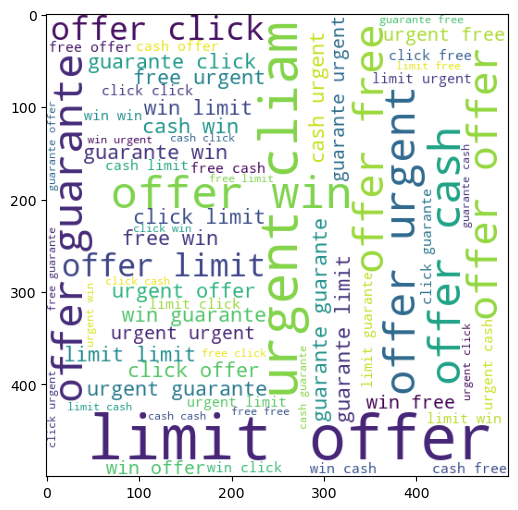

In [253]:
plt.figure(figsize=(15,6))
plt.imshow(spam_wc)

In [255]:

ham_wc = wc.generate(df[df['label'] == 0]['transformed_text'].str.cat(sep=" "))

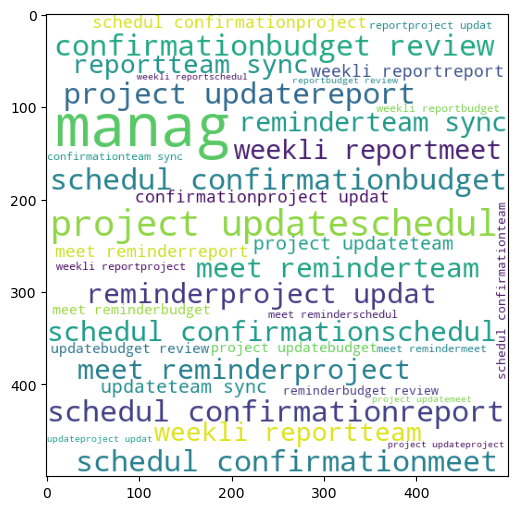

In [256]:
plt.figure(figsize=(15,6))
plt.imshow(ham_wc)

In [257]:
spam_corpus = []
for msg in df[df['label'] == 1]['transformed_text'].tolist():
    for word in msg.split():
        spam_corpus.append(word)
        

In [258]:

len(spam_corpus)

80183

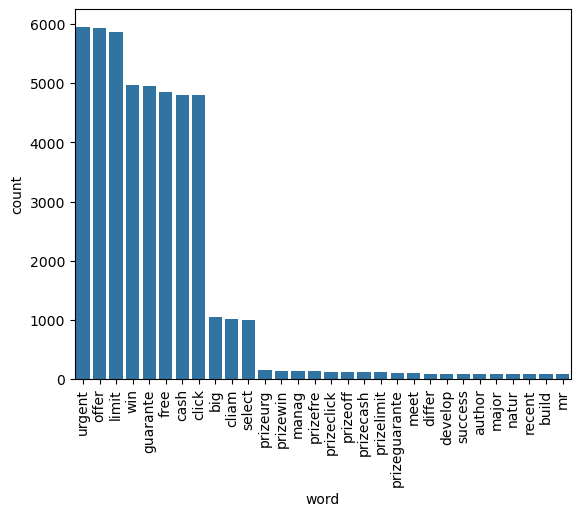

In [260]:
from collections import Counter
common_spam = pd.DataFrame(
    Counter(spam_corpus).most_common(30),
    columns=['word', 'count']
)

sns.barplot(
    x='word',
    y='count',
    data=common_spam
)

plt.xticks(rotation='vertical')

plt.show()

In [262]:
ham_corpus = []
for msg in df[df['label'] == 0]['transformed_text'].tolist():
    for word in msg.split():
        ham_corpus.append(word)

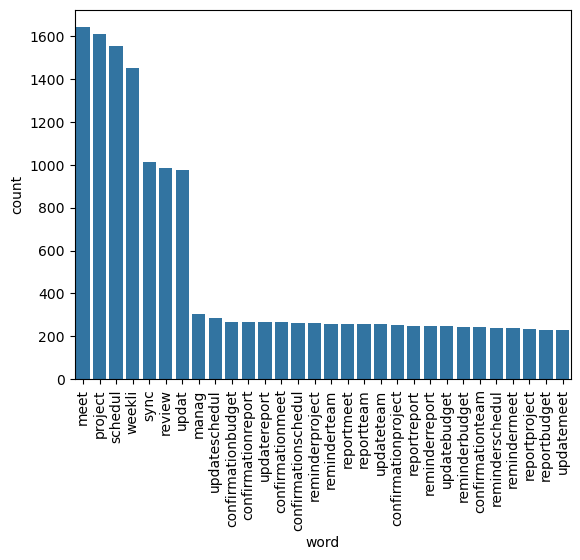

In [263]:
from collections import Counter
common_spam = pd.DataFrame(
    Counter(ham_corpus).most_common(30),
    columns=['word', 'count']
)

sns.barplot(
    x='word',
    y='count',
    data=common_spam
)

plt.xticks(rotation='vertical')

plt.show()

In [274]:
df.shape

(10000, 7)

In [129]:
TF-IDF VECTORIZATION


SyntaxError: invalid syntax (4252295958.py, line 1)

In [130]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [131]:
tfidf = TfidfVectorizer(
    max_features=3000
)

In [132]:
X_text = tfidf.fit_transform(
    df['transformed_text']
).toarray()

In [269]:
tfidf.get_feature_names_out()

array(['abil', 'abl', 'accept', 'accord', 'account', 'across', 'act',
       'action', 'activ', 'actual', 'add', 'address', 'administr',
       'admit', 'adult', 'affect', 'age', 'agenc', 'agent', 'ago', 'agre',
       'agreement', 'ahead', 'air', 'allow', 'almost', 'alon', 'along',
       'alreadi', 'also', 'although', 'alway', 'american', 'among',
       'amount', 'analysi', 'anim', 'anoth', 'answer', 'anyon', 'anyth',
       'appear', 'appli', 'approach', 'area', 'argu', 'arm', 'around',
       'arriv', 'art', 'articl', 'artist', 'ask', 'assum', 'attack',
       'attent', 'attorney', 'audienc', 'author', 'avail', 'avoid',
       'away', 'babi', 'back', 'bad', 'bag', 'ball', 'bank', 'bar',
       'base', 'beat', 'beauti', 'becom', 'bed', 'begin', 'behavior',
       'behind', 'believ', 'benefit', 'best', 'better', 'beyond', 'big',
       'bill', 'billion', 'bit', 'black', 'blood', 'blue', 'board',
       'bodi', 'book', 'born', 'box', 'boy', 'break', 'bring', 'brother',
       'budget

In [48]:
X_text.shape

(10000, 883)

In [275]:
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   num_words               10000 non-null  int64 
 1   num_characters          10000 non-null  int64 
 2   contains_money_terms    10000 non-null  int64 
 3   contains_urgency_terms  10000 non-null  int64 
 4   num_sentences           10000 non-null  int64 
 5   label                   10000 non-null  int64 
 6   transformed_text        10000 non-null  object
dtypes: int64(6), object(1)
memory usage: 547.0+ KB


In [51]:
numeric_features = df[
    [
        'num_words',
        'num_characters',
        'contains_money_terms',
        'contains_urgency_terms',
        'num_sentences'
    ]
].values

In [52]:
X = np.hstack(
    (
        X_text,
        numeric_features
    ))
y = df['label']

In [53]:
print(X.shape)

(10000, 888)


In [ ]:
TRAIN TEST SPLIT

In [54]:

from sklearn.model_selection import train_test_split

In [55]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [56]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score


In [57]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()


In [58]:
gnb.fit(X_train,y_train)
y_pred1 = gnb.predict(X_test)
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1))

1.0
[[1196    0]
 [   0  804]]
1.0


In [59]:
mnb.fit(X_train,y_train)
y_pred2 = mnb.predict(X_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))

1.0
[[1196    0]
 [   0  804]]
1.0


In [60]:
bnb.fit(X_train,y_train)
y_pred3 = bnb.predict(X_test)
print(accuracy_score(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))
print(precision_score(y_test,y_pred3))

1.0
[[1196    0]
 [   0  804]]
1.0


In [61]:
X = X_text

In [292]:
df['transformed_text'].duplicated().sum()

np.int64(0)

In [293]:
X.shape

(10000, 883)

In [295]:
X

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(10000, 883))

In [62]:
numeric_features = df[
    [
        'num_words',
        'num_characters',
        'num_sentences'
    ]
].values

In [63]:
X = np.hstack(
    (
        X_text,
        numeric_features
    )
)

y = df['label']

array([[0., 0., 0., ..., 0., 0., 3.],
       [0., 0., 0., ..., 1., 0., 3.],
       [0., 0., 0., ..., 1., 1., 1.],
       ...,
       [0., 0., 0., ..., 0., 1., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 2.]], shape=(10000, 888))

In [64]:
print(X.shape)

(10000, 886)


In [65]:

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [66]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [67]:
gnb.fit(X_train,y_train)
y_pred1 = gnb.predict(X_test)
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1))

1.0
[[1196    0]
 [   0  804]]
1.0


In [68]:
mnb.fit(X_train,y_train)
y_pred2 = mnb.predict(X_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))

1.0
[[1196    0]
 [   0  804]]
1.0


In [69]:

bnb.fit(X_train,y_train)
y_pred3 = bnb.predict(X_test)
print(accuracy_score(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))
print(precision_score(y_test,y_pred3))

1.0
[[1196    0]
 [   0  804]]
1.0


In [80]:
X = tfidf.fit_transform(
    df['transformed_text']
).toarray()

In [81]:
X.shape

(10000, 883)

In [82]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [83]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [84]:
gnb.fit(X_train,y_train)
y_pred1 = gnb.predict(X_test)
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1))

1.0
[[1181    0]
 [   0  819]]
1.0


In [85]:
mnb.fit(X_train,y_train)
y_pred2 = mnb.predict(X_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))


1.0
[[1181    0]
 [   0  819]]
1.0


In [86]:
bnb.fit(X_train,y_train)
y_pred3 = bnb.predict(X_test)
print(accuracy_score(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))
print(precision_score(y_test,y_pred3))

1.0
[[1181    0]
 [   0  819]]
1.0


In [79]:
df.groupby('label')['transformed_text'].nunique()

label
0    6005
1    3995
Name: transformed_text, dtype: int64

In [331]:
df[df['label']==1]['transformed_text'].sample(10).tolist()

['limit offer free click urgent guarante cash free click cash limit guarante free bad accept like detail',
 'urgent cliam prizeurg limit cash offer free guarante urgent limit limit guarante free offer win senior especi experi space former upon',
 'limit offer cash free win offer urgent urgent win guarante click urgent guy cost director feder away appli sell attack reason suddenli',
 'big win offer free offer cash free control sound becom oil artist govern west even',
 'big urgent offer win click cash limit guarante bar abil discuss congress famili open',
 'select click free win cash win rate probabl son buy woman mr kid bit environ',
 'select win urgent limit limit offer urgent offer offer product parti peopl avoid seriou choic',
 'urgent cliam prizefre urgent win free click free cash click offer click guarante limit offer offer win learn describ glass improv pay discov husband',
 'limit offer cash cash offer offer win free win offer cash urgent sort heavi black everyon vote amount cen

In [332]:
df[df['label']==0]['transformed_text'].sample(10).tolist()

['project updateteam sync often eight militari writer skill court thu anyon ago govern beauti use reveal game road futur presid particularli long evid articl figur',
 'project updateteam sync imagin town pull pick ball compar rest center approach size million wonder glass shake trial',
 'schedul confirmationteam sync writer rise lose draw everybodi discov kind help sort intern finish street market word region long',
 'meet reminderteam sync cup catch mean author idea fear blue treatment movement polit decad thought tonight pictur rest',
 'schedul confirmationteam sync religi project ball suffer certain one music reduc modern agreement',
 'weekli reportmeet econom feder stop school task cover southern mr suffer ga',
 'weekli reportteam sync career court center run mean network small mind us',
 'schedul confirmationschedul necessari upon major write learn resourc travel includ place prepar',
 'weekli reportmeet skill capit option serv interest perform claim signific',
 'schedul confirmat

In [334]:
!pip install xgboost

  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
Using cached xgboost-3.2.0-py3-none-win_amd64.whl (101.7 MB)


In [121]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [122]:
svc = SVC(kernel='sigmoid', gamma=1.0)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver='liblinear', penalty='l1')
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
abc = AdaBoostClassifier(n_estimators=50, random_state=2)
bc = BaggingClassifier(n_estimators=50, random_state=2)
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
gbdt = GradientBoostingClassifier(n_estimators=50,random_state=2)
xgb = XGBClassifier(n_estimators=50,random_state=2)

In [123]:
clfs = {
    'SVC' : svc,
    'KN' : knc, 
    'NB': mnb, 
    'DT': dtc, 
    'LR': lrc, 
    'RF': rfc, 
    'AdaBoost': abc, 
    'BgC': bc, 
    'ETC': etc,
    'GBDT':gbdt,
    'xgb':xgb
}


In [139]:
X = tfidf.fit_transform(
    df['transformed_text']
).toarray()

y = df['label'].values

In [140]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [141]:
def train_classifier(clf,X_train,y_train,X_test,y_test):
    clf.fit(X_train,y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test,y_pred)
    precision = precision_score(y_test,y_pred)
    
    return accuracy,precision

In [142]:
train_classifier(svc,X_train,y_train,X_test,y_test)

(1.0, 1.0)

In [143]:
accuracy_scores = []
precision_scores = []

for name,clf in clfs.items():
    
    current_accuracy,current_precision = train_classifier(clf, X_train,y_train,X_test,y_test)
    
    print("For ",name)
    print("Accuracy - ",current_accuracy)
    print("Precision - ",current_precision)
    
    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

For  SVC
Accuracy -  1.0
Precision -  1.0


D:\Users\DELL\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "D:\Users\DELL\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "D:\Users\DELL\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "D:\Users\DELL\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^

For  KN
Accuracy -  0.988
Precision -  0.9710144927536232
For  NB
Accuracy -  1.0
Precision -  1.0
For  DT
Accuracy -  0.999
Precision -  1.0
For  LR
Accuracy -  1.0
Precision -  1.0
For  RF
Accuracy -  1.0
Precision -  1.0
For  AdaBoost
Accuracy -  0.9995
Precision -  1.0
For  BgC
Accuracy -  0.9995
Precision -  1.0
For  ETC
Accuracy -  1.0
Precision -  1.0
For  GBDT
Accuracy -  1.0
Precision -  1.0
For  xgb
Accuracy -  0.9995
Precision -  1.0


In [ ]:
Final Model Selection

Multinomial Naive Bayes was selected as the final model because it is well-suited for
sparse TF-IDF based text classification tasks and performed efficiently on the dataset.

In [88]:
from sklearn.pipeline import Pipeline

In [89]:
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=3000)),
    ('model', MultinomialNB())
])

In [90]:
X = df['transformed_text']

y = df['label']

In [91]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [92]:
pipeline.fit(X_train, y_train)

,steps,"[('tfidf', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


In [93]:
y_pred = pipeline.predict(X_test)

In [94]:
from sklearn.metrics import accuracy_score

print(accuracy_score(y_test, y_pred))

1.0


In [ ]:
MODEL PICKLING

In [95]:
import pickle

pickle.dump(
    pipeline,
    open('pipeline.pkl', 'wb')
)

In [96]:
pipe = pickle.load(
    open('pipeline.pkl', 'rb')
)

In [97]:
sample = "urgent claim your reward now"

prediction = pipe.predict([sample])

print(prediction)

[1]


In [ ]:
Observations and Limitations

Several models achieved near-perfect performance on the dataset, including 100% 
accuracy and precision.

This suggests that the dataset contains highly separable patterns between spam and 
non-spam emails.

In [154]:
import os

os.getcwd()


'C:\\Users\\DELL\\machine learning project\\email-spam-classifier'